# Train Split EDA

Minimal exploratory data analysis for the Kaggle Speech Recognition Challenge train split.

This notebook uses `speech_recognition.SpeechCommandsDataset` to:
- load/train split
- inspect class distribution
- inspect audio duration distribution
- inspect sample rate distribution
- inspect stats for the report

In [1]:
%load_ext autoreload
%autoreload 2
%config InlineBackend.figure_format = "retina"

In [2]:
import wave
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from tqdm.auto import tqdm

from speech_recognition import SpeechCommandsDataset

sns.set_theme(style="whitegrid")
sns.set_palette("Set2")

## Load dataset manager and train split

In [3]:
dataset = SpeechCommandsDataset(
    auto_download=True,
    only_1sec_samples=False,
    use_extended_dataset=True,
)
train_samples = dataset.train

print("Dataset root:", dataset.dataset_root)
print("Stats:", dataset.stats())
print("Train samples:", len(train_samples))

2026-04-12 22:34:12,002 - speech_recognition.dataset.unknown - INFO - Creating __unknown__ label samples as interpolation of existing samples.
2026-04-12 22:35:41,723 - speech_recognition.dataset.unknown - WARNING - Skipping interpolation of ['/Users/pawelp/Desktop/education/pw/deepl/speech-recognition/src/../data/kaggle_speech_commands/tensorflow-speech-recognition-challenge/train/audio/off/bdb26021_nohash_2.wav', '/Users/pawelp/Desktop/education/pw/deepl/speech-recognition/src/../data/kaggle_speech_commands/tensorflow-speech-recognition-challenge/train/audio/marvin/964e8cfd_nohash_0.wav', '/Users/pawelp/Desktop/education/pw/deepl/speech-recognition/src/../data/kaggle_speech_commands/tensorflow-speech-recognition-challenge/train/audio/zero/d90b4138_nohash_2.wav'] because no blended audio was produced.
2026-04-12 22:38:46,593 - speech_recognition.dataset.unknown - WARNING - Skipping interpolation of ['/Users/pawelp/Desktop/education/pw/deepl/speech-recognition/src/../data/kaggle_speech

Dataset root: /Users/pawelp/Desktop/education/pw/deepl/speech-recognition/src/../data/kaggle_speech_commands/tensorflow-speech-recognition-challenge
Stats: {'train': 61797, 'val': 6661, 'test': 6661}
Train samples: 61797


## Build train metadata table

In [4]:
def read_wav_meta(path: Path) -> tuple[int, int, float, int]:
    """Return (sample_rate, n_frames, duration_sec, sample_width_bytes)."""
    with wave.open(str(path), "rb") as wav_file:
        sample_rate = wav_file.getframerate()
        n_frames = wav_file.getnframes()
        sample_width = wav_file.getsampwidth()
    duration_sec = n_frames / float(sample_rate) if sample_rate else 0.0
    return sample_rate, n_frames, duration_sec, sample_width


rows: list[dict[str, object]] = []
for sample in tqdm(train_samples, desc="Reading train metadata"):
    sample_rate, n_frames, duration_sec, sample_width = read_wav_meta(sample.path)
    rows.append(
        {
            "path": str(sample.path),
            "filename": sample.filename,
            "label": sample.label,
            "sample_rate": sample_rate,
            "n_frames": n_frames,
            "duration_sec": duration_sec,
            "sample_width_bytes": sample_width,
        }
    )

train_df = pd.DataFrame(rows)
train_df.head()

Reading train metadata:   0%|          | 0/61797 [00:00<?, ?it/s]

,path,filename,label,sample_rate,n_frames,duration_sec,sample_width_bytes
0,/Users/pawelp/Desktop/education/pw/deepl/speec...,unknown_0.wav,__unknown__,16000,16000,1.000000,2
1,/Users/pawelp/Desktop/education/pw/deepl/speec...,unknown_1.wav,__unknown__,16000,13654,0.853375,2
2,/Users/pawelp/Desktop/education/pw/deepl/speec...,unknown_10.wav,__unknown__,16000,16000,1.000000,2
3,/Users/pawelp/Desktop/education/pw/deepl/speec...,unknown_100.wav,__unknown__,16000,16000,1.000000,2
4,/Users/pawelp/Desktop/education/pw/deepl/speec...,unknown_1001.wav,__unknown__,16000,15019,0.938688,2


## Basic summary

In [5]:
train_df.describe(include="all").transpose().head(20)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
path,61797,61797,/Users/pawelp/Desktop/education/pw/deepl/speec...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
filename,61797,16136,46a153d8_nohash_0.wav,30,NaN,NaN,NaN,NaN,NaN,NaN,NaN
label,61797,32,__unknown__,9683,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sample_rate,61797.0,NaN,NaN,NaN,16000.0,0.0,16000.0,16000.0,16000.0,16000.0,16000.0
n_frames,61797.0,NaN,NaN,NaN,15595.150379,1250.829289,5945.0,16000.0,16000.0,16000.0,16000.0
duration_sec,61797.0,NaN,NaN,NaN,0.974697,0.078177,0.371563,1.0,1.0,1.0,1.0
sample_width_bytes,61797.0,NaN,NaN,NaN,2.0,0.0,2.0,2.0,2.0,2.0,2.0


In [6]:
print("Unique labels:", train_df["label"].nunique())
print("Unique sample rates:", sorted(train_df["sample_rate"].dropna().unique().tolist()))
print("Duration range (sec):", train_df["duration_sec"].min(), "->", train_df["duration_sec"].max())

Unique labels: 32
Unique sample rates: [16000]
Duration range (sec): 0.3715625 -> 1.0


## Class distribution (train)

In [7]:
label_counts = train_df["label"].value_counts().rename_axis("label").reset_index(name="count")
label_counts.head()

,label,count
0,__unknown__,9683
1,down,1911
2,seven,1911
3,two,1908
4,yes,1908


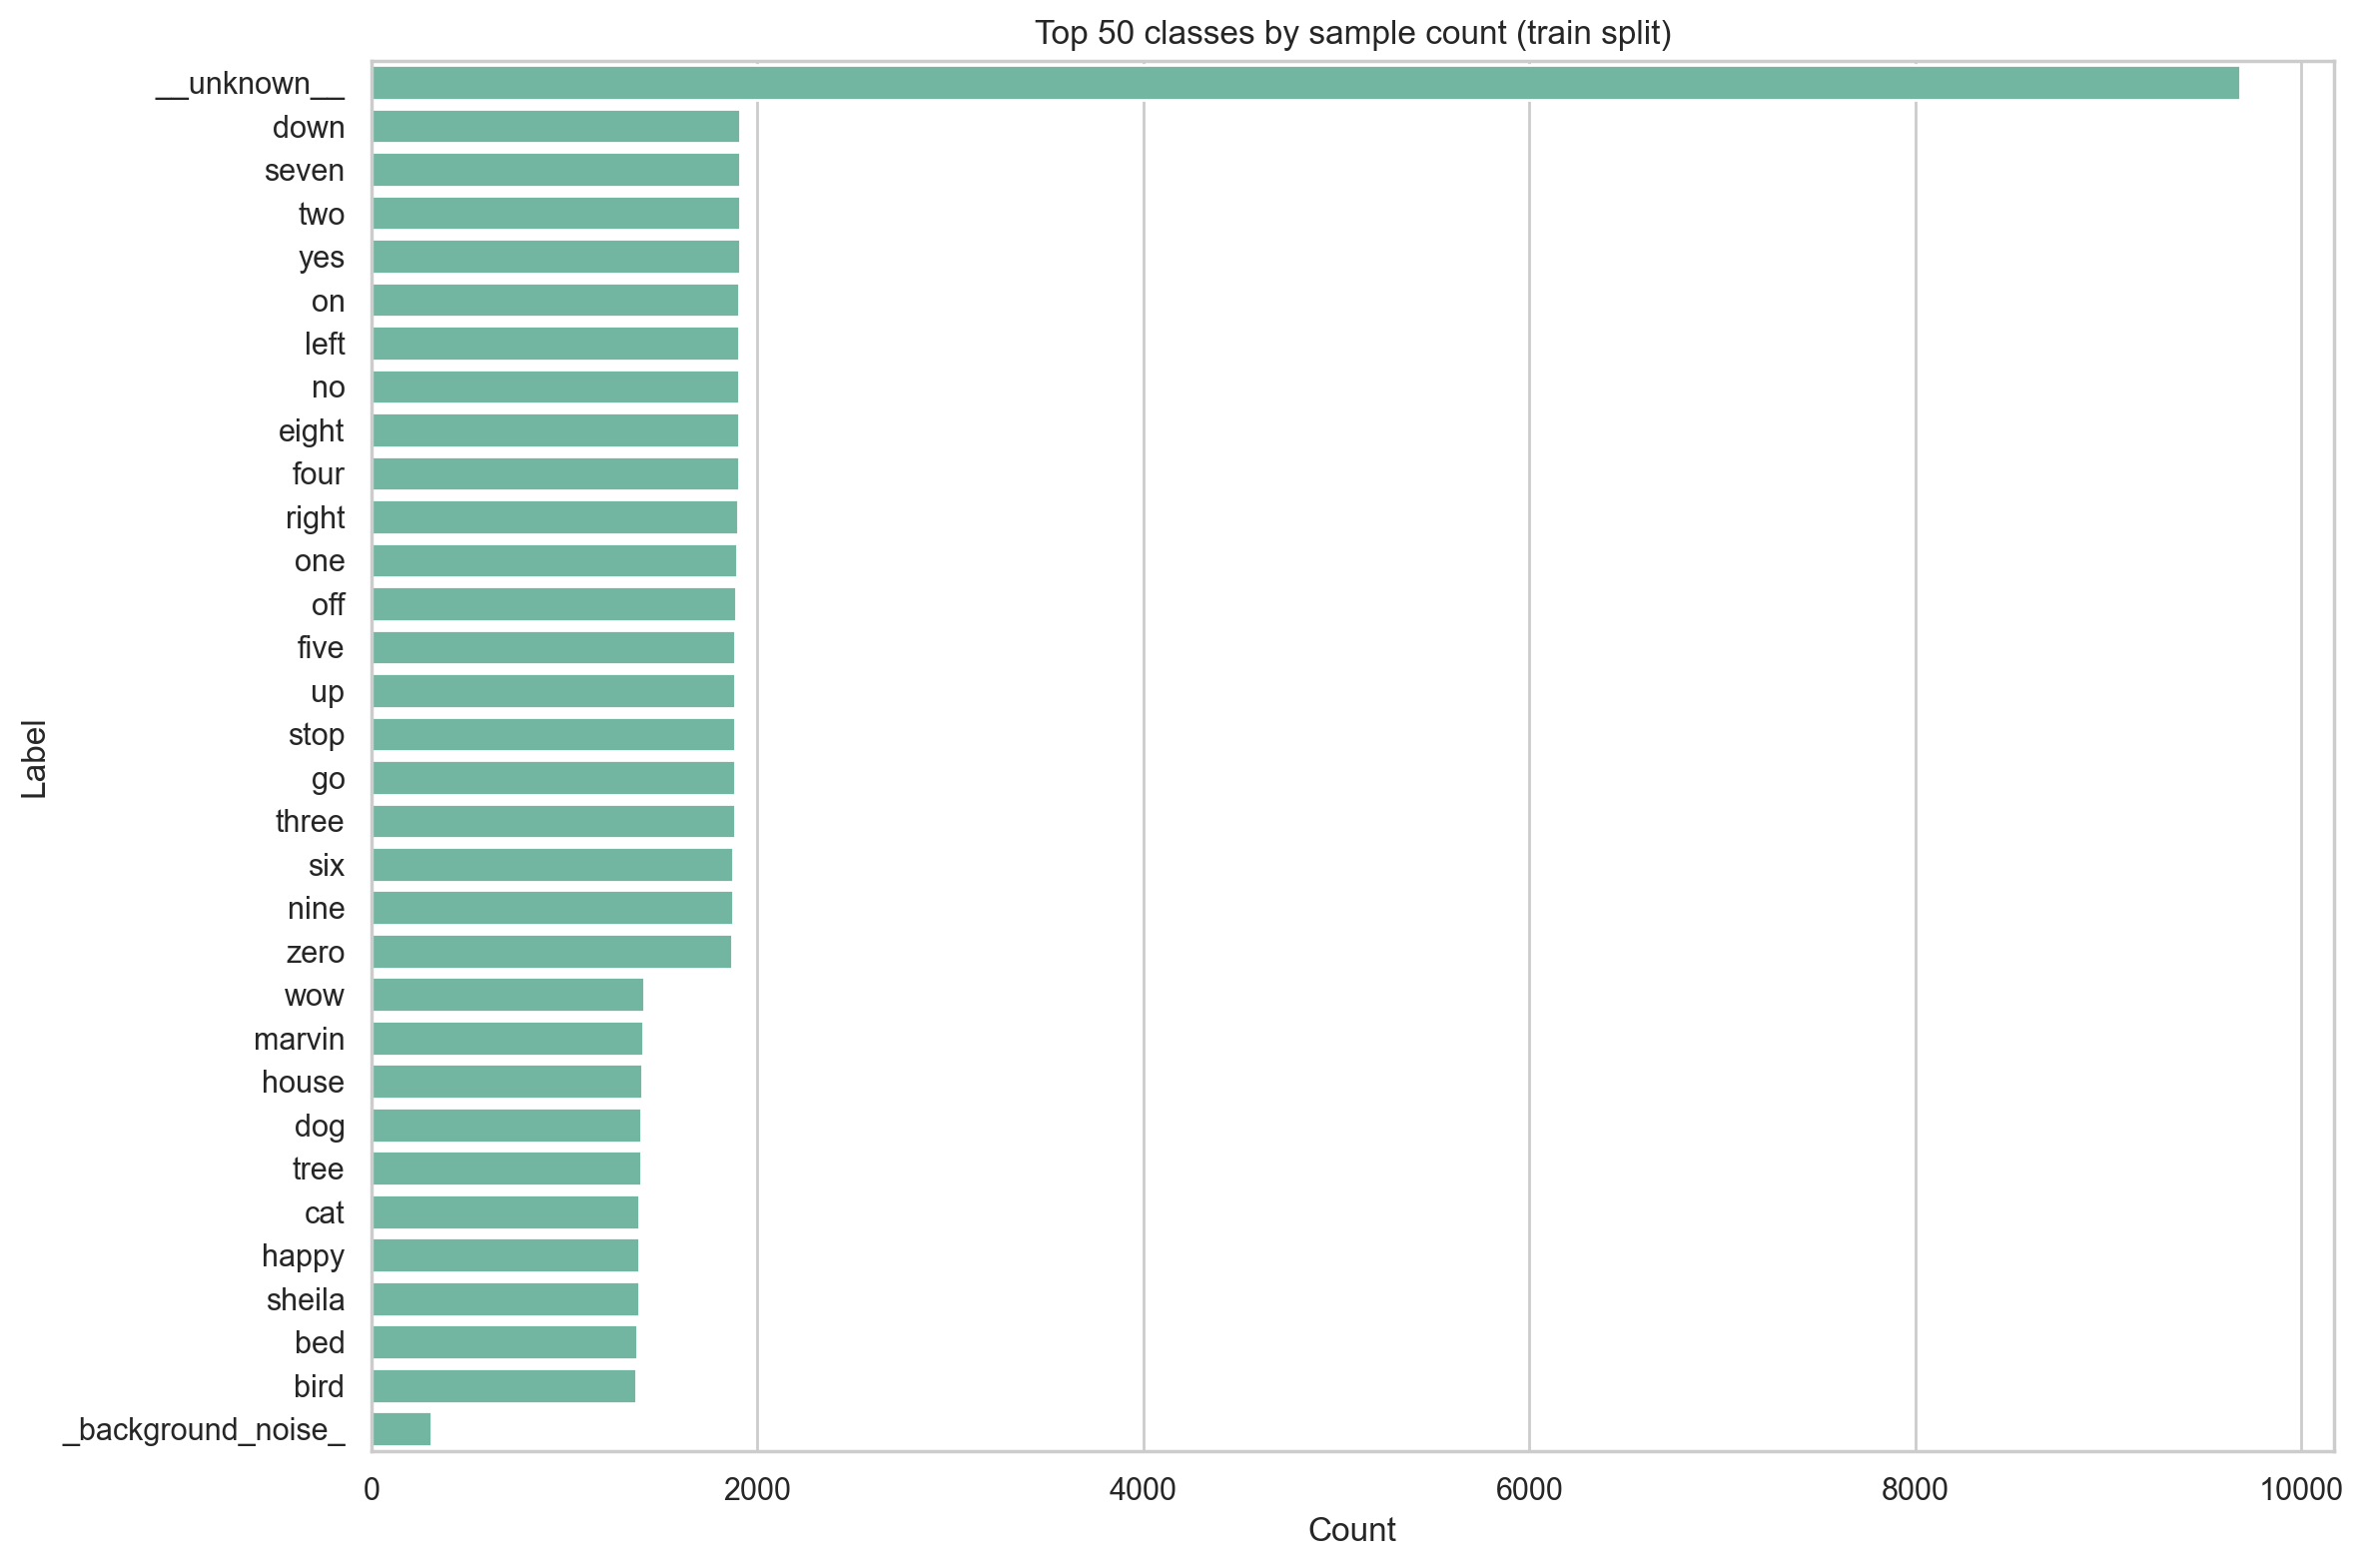

In [8]:
top_n = 50
plot_df = label_counts.head(top_n)

plt.figure(figsize=(12, 8))
sns.barplot(data=plot_df, y="label", x="count", legend=False)
plt.title(f"Top {top_n} classes by sample count (train split)")
plt.xlabel("Count")
plt.ylabel("Label")
plt.tight_layout()
plt.show()

## Duration analysis

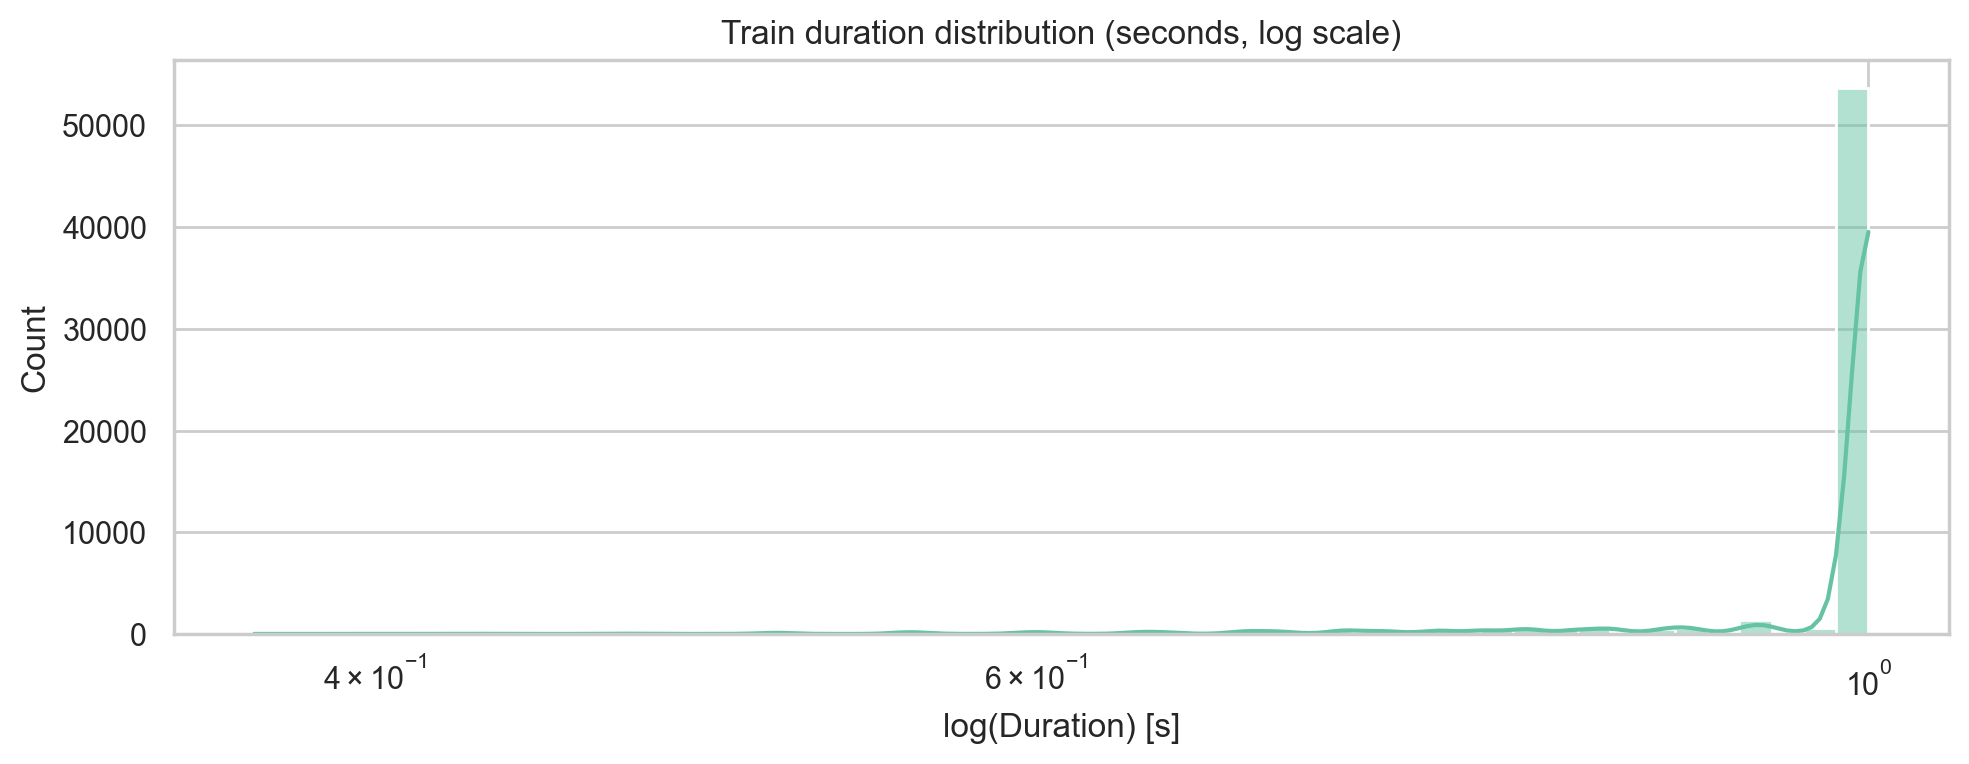

In [9]:
plt.figure(figsize=(10, 4))
sns.histplot(train_df["duration_sec"], bins=50, kde=True, log_scale=True)
plt.title("Train duration distribution (seconds, log scale)")
plt.xlabel("log(Duration) [s]")
plt.tight_layout()
plt.show()

In [10]:
duration_by_label = (
    train_df.groupby("label", as_index=False)["duration_sec"]
    .agg(["count", "mean", "std", "min", "max"])
    .reset_index()
)
duration_by_label.head(10)

,index,label,count,mean,std,min,max
0,0,__unknown__,9683,0.921992,0.128758,0.371563,1.0
1,1,_background_noise_,311,1.000000,0.000000,1.000000,1.0
2,2,bed,1379,0.981259,0.061012,0.469375,1.0
3,3,bird,1371,0.980071,0.067507,0.512000,1.0
4,4,cat,1389,0.981579,0.061839,0.510875,1.0
5,5,dog,1397,0.982562,0.061637,0.464438,1.0
6,6,down,1911,0.986210,0.054082,0.512000,1.0
7,7,eight,1902,0.984841,0.058412,0.418000,1.0
8,8,five,1886,0.986910,0.056193,0.510875,1.0
9,9,four,1902,0.985182,0.060736,0.512000,1.0


## Sample rate and sample width analysis

In [11]:
sr_counts = train_df["sample_rate"].value_counts().sort_index()
sw_counts = train_df["sample_width_bytes"].value_counts().sort_index()

print("Sample rate counts:")
display(sr_counts)

print("Sample width counts (bytes):")
display(sw_counts)

Sample rate counts:


sample_rate
16000    61797
Name: count, dtype: int64

Sample width counts (bytes):


sample_width_bytes
2    61797
Name: count, dtype: int64

In [12]:
rng = np.random.default_rng(42)
n_examples = 6
example_indices = rng.choice(len(train_df), size=min(n_examples, len(train_df)), replace=False)
examples = train_df.iloc[example_indices].reset_index(drop=True)
examples[["label", "filename", "duration_sec", "sample_rate"]]

,label,filename,duration_sec,sample_rate
0,one,edd8bfe3_nohash_0.wav,1.0,16000
1,stop,1cbcc7a7_nohash_0.wav,1.0,16000
2,house,402e2977_nohash_0.wav,1.0,16000
3,two,24befdb3_nohash_1.wav,1.0,16000
4,house,84999496_nohash_0.wav,1.0,16000
5,__unknown__,unknown_6154.wav,1.0,16000


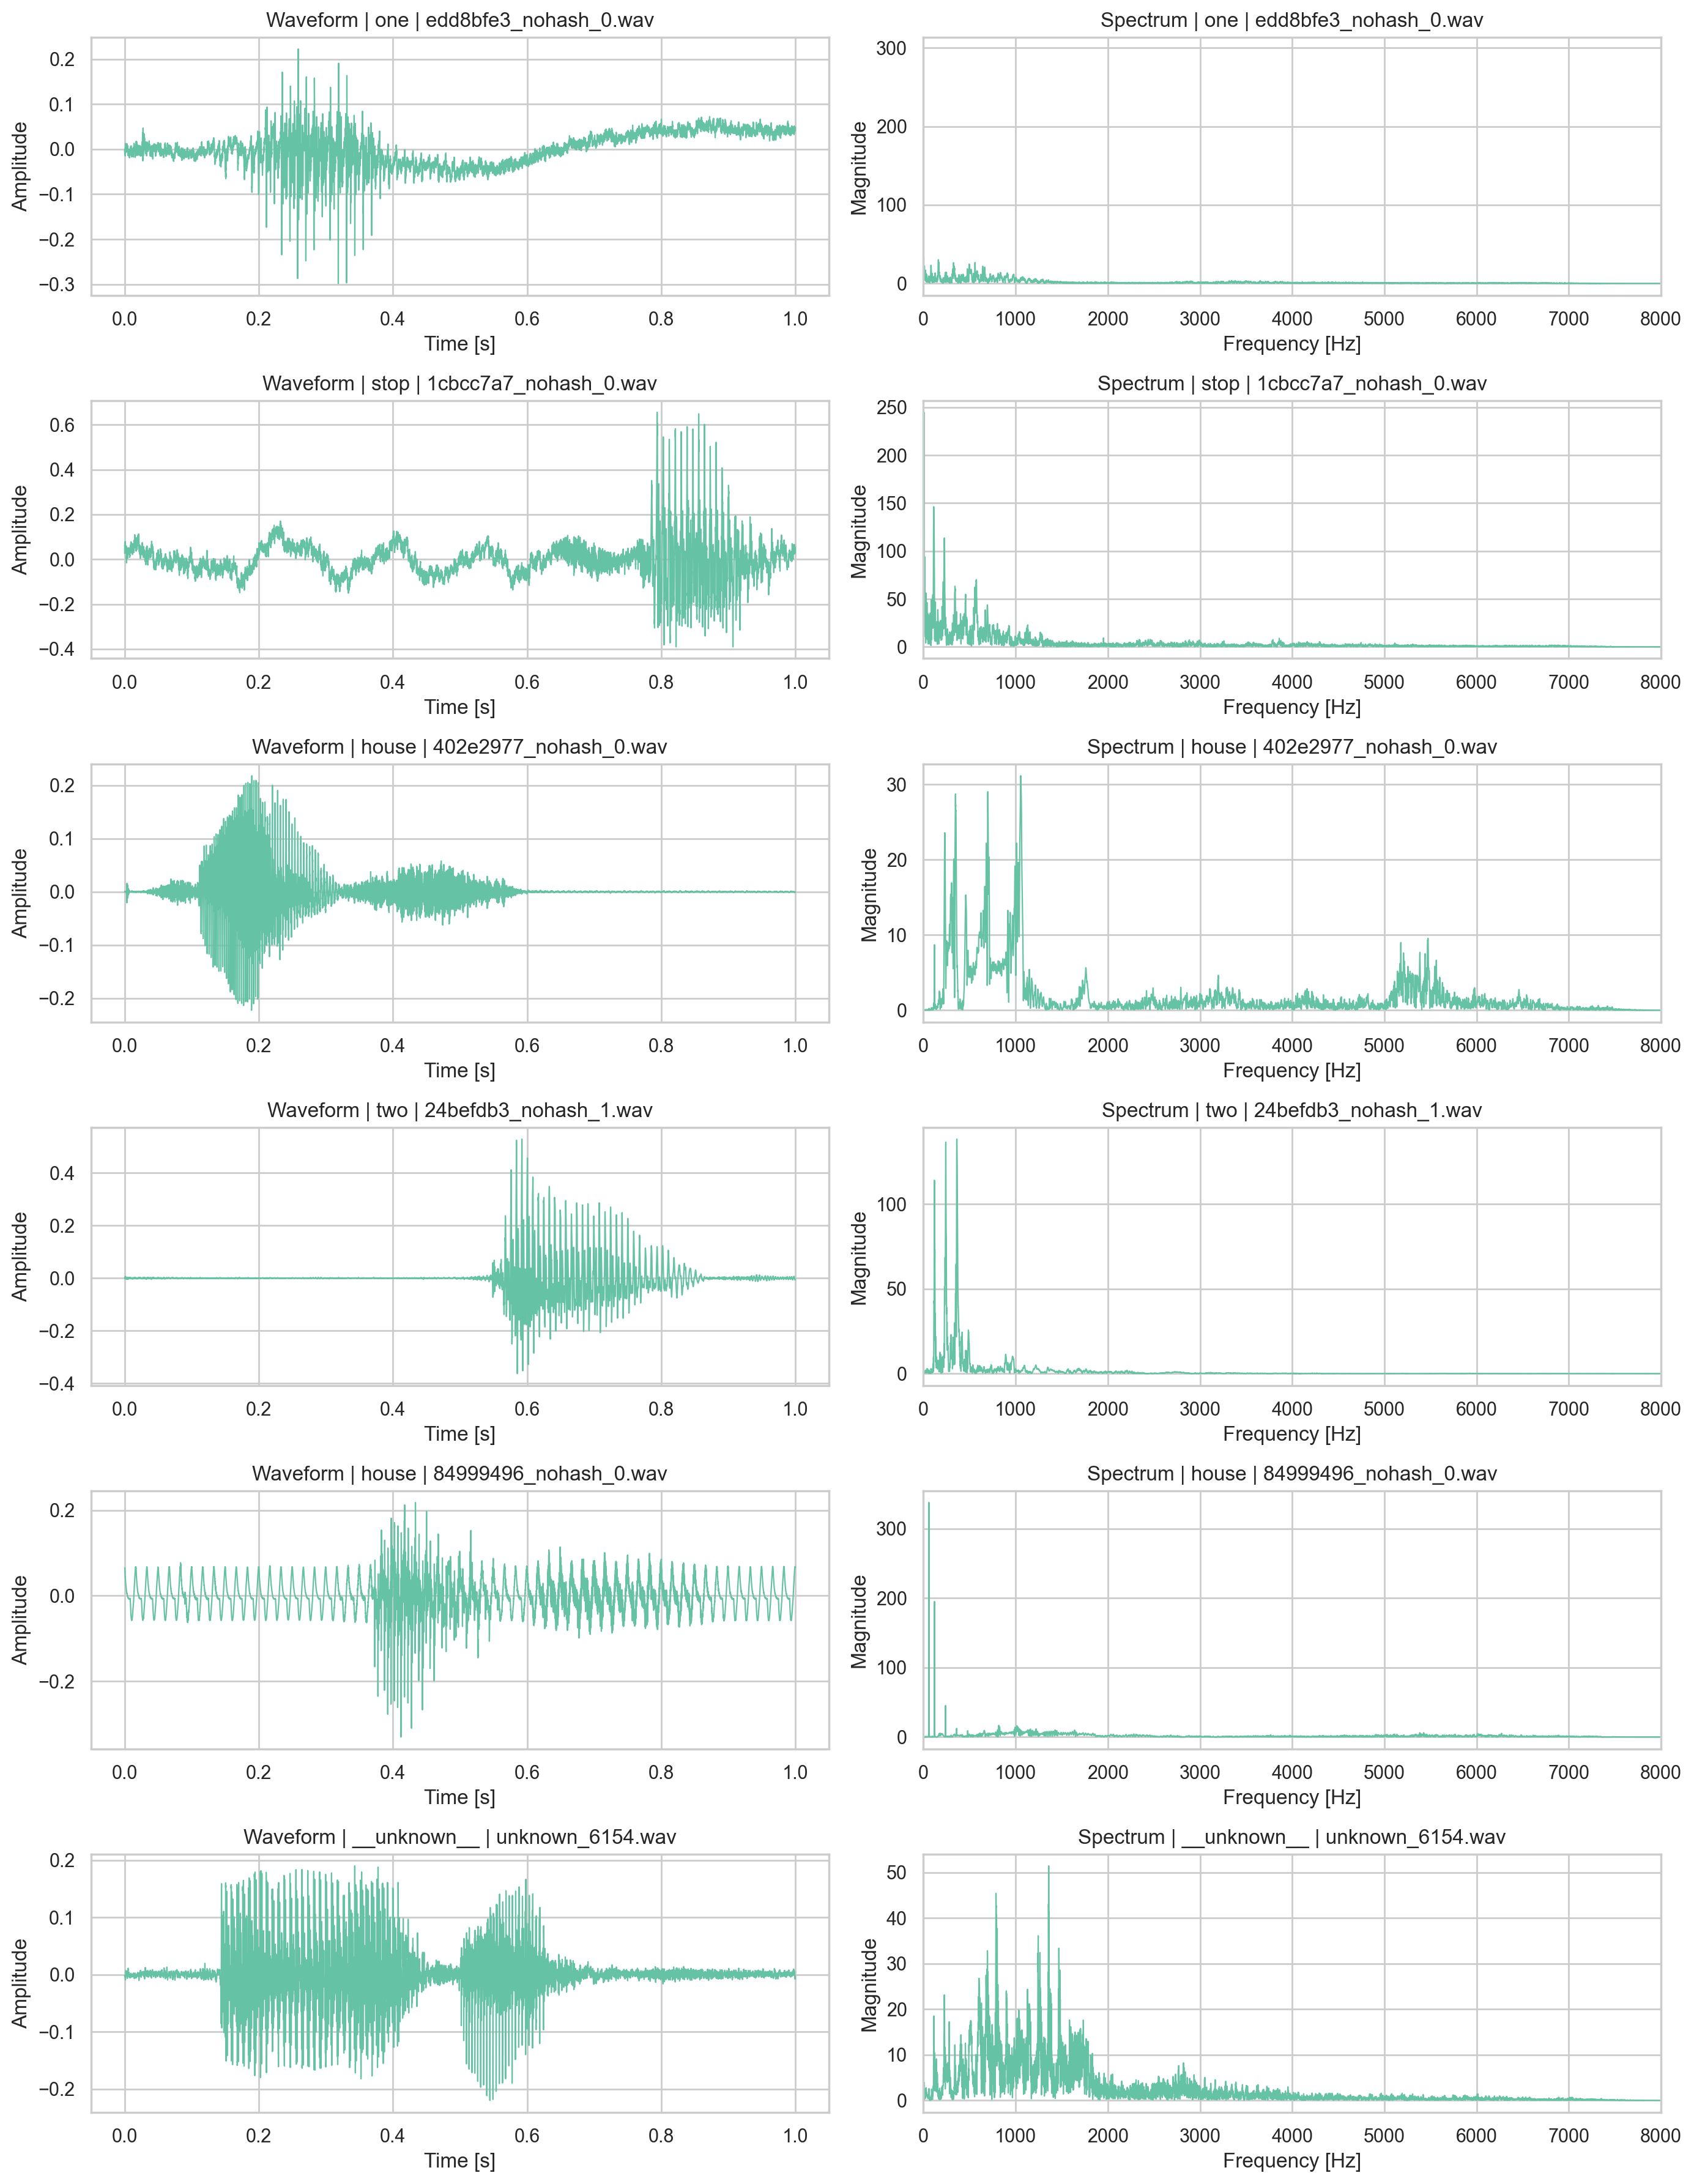

In [13]:
def read_pcm16_mono(path: Path) -> tuple[np.ndarray, int]:
    """Read wav file as float waveform and return (signal, sample_rate)."""
    with wave.open(str(path), "rb") as wav_file:
        sample_rate = wav_file.getframerate()
        n_channels = wav_file.getnchannels()
        sample_width = wav_file.getsampwidth()
        frames = wav_file.readframes(wav_file.getnframes())

    if sample_width != 2:
        raise ValueError(
            f"Expected 16-bit PCM wav, got sample_width={sample_width} bytes for {path}"
        )

    signal = np.frombuffer(frames, dtype=np.int16).astype(np.float32) / 32768.0
    if n_channels > 1:
        signal = signal.reshape(-1, n_channels).mean(axis=1)

    return signal, sample_rate


fig, axes = plt.subplots(nrows=len(examples), ncols=2, figsize=(14, 3 * len(examples)))
if len(examples) == 1:
    axes = np.array([axes])

for i, row in examples.iterrows():
    signal, sr = read_pcm16_mono(Path(row["path"]))
    t = np.arange(signal.shape[0]) / sr

    # Waveform
    ax_w = axes[i, 0]
    ax_w.plot(t, signal, linewidth=0.8)
    ax_w.set_title(f"Waveform | {row['label']} | {row['filename']}")
    ax_w.set_xlabel("Time [s]")
    ax_w.set_ylabel("Amplitude")

    # Magnitude spectrum
    ax_s = axes[i, 1]
    fft_vals = np.fft.rfft(signal)
    fft_freqs = np.fft.rfftfreq(signal.shape[0], d=1.0 / sr)
    magnitude = np.abs(fft_vals)
    ax_s.plot(fft_freqs, magnitude, linewidth=0.8)
    ax_s.set_title(f"Spectrum | {row['label']} | {row['filename']}")
    ax_s.set_xlabel("Frequency [Hz]")
    ax_s.set_ylabel("Magnitude")
    ax_s.set_xlim(0, min(8000, sr // 2))

plt.tight_layout()
plt.show()

# Stats for report

In [14]:
# Build val and test metadata tables
def analyze_split(samples, split_name):
    """Analyze a split (val or test) and return statistics."""
    rows: list[dict[str, object]] = []
    for sample in tqdm(samples, desc=f"Reading {split_name} metadata"):
        sample_rate, n_frames, duration_sec, sample_width = read_wav_meta(sample.path)
        rows.append(
            {
                "path": str(sample.path),
                "filename": sample.filename,
                "label": sample.label,
                "sample_rate": sample_rate,
                "n_frames": n_frames,
                "duration_sec": duration_sec,
                "sample_width_bytes": sample_width,
            }
        )
    return pd.DataFrame(rows)


val_samples = dataset.val
test_samples = dataset.test

val_df = analyze_split(val_samples, "val")
test_df = analyze_split(test_samples, "test")

print(f"Validation split: {len(val_df)} samples")
print(f"Test split: {len(test_df)} samples")

Reading val metadata:   0%|          | 0/6661 [00:00<?, ?it/s]

Reading test metadata:   0%|          | 0/6661 [00:00<?, ?it/s]

Validation split: 6661 samples
Test split: 6661 samples


In [15]:
# Comprehensive stats for all splits
print("=" * 100)
print("COMPREHENSIVE DATASET STATISTICS FOR ALL SPLITS (FOR REPORT)")
print("=" * 100)

splits_data = {
    "train": (train_df, len(train_df)),
    "val": (val_df, len(val_df)),
    "test": (test_df, len(test_df)),
}

for split_name, (df, total_count) in splits_data.items():
    print(f"\n{split_name.upper()} SPLIT")
    print("-" * 100)
    print(f"Total samples: {total_count:,}")
    print(f"Unique classes: {df['label'].nunique()}")
    print(f"Unique sample rates: {sorted(df['sample_rate'].dropna().unique().tolist())}")
    print("\nDuration statistics (seconds):")
    print(f"  Min:    {df['duration_sec'].min():.4f}")
    print(f"  Max:    {df['duration_sec'].max():.4f}")
    print(f"  Mean:   {df['duration_sec'].mean():.4f}")
    print(f"  Median: {df['duration_sec'].median():.4f}")
    print(f"  Std:    {df['duration_sec'].std():.4f}")
    print(
        f"  1.0s:   {(df['duration_sec'] == 1.0).sum()} samples "
        f"({(df['duration_sec'] == 1.0).sum() / total_count * 100:.1f}%)"
    )

    # Frame statistics
    print("\nFrame statistics (at 16 kHz):")
    print(f"  Min frames:    {df['n_frames'].min():,}")
    print(f"  Max frames:    {df['n_frames'].max():,}")
    print(f"  Mean frames:   {df['n_frames'].mean():.0f}")
    print(
        f"  16000 frames:  {(df['n_frames'] == 16000).sum()} samples "
        f"({(df['n_frames'] == 16000).sum() / total_count * 100:.1f}%)"
    )

    # Class distribution for split
    top_classes = df["label"].value_counts().head(5)
    print("\nTop 5 classes:")
    for label, count in top_classes.items():
        pct = count / total_count * 100
        print(f"  {label:20s}: {count:5d} ({pct:5.2f}%)")

print("\n" + "=" * 100)

COMPREHENSIVE DATASET STATISTICS FOR ALL SPLITS (FOR REPORT)

TRAIN SPLIT
----------------------------------------------------------------------------------------------------
Total samples: 61,797
Unique classes: 32
Unique sample rates: [16000]

Duration statistics (seconds):
  Min:    0.3716
  Max:    1.0000
  Mean:   0.9747
  Median: 1.0000
  Std:    0.0782
  1.0s:   52916 samples (85.6%)

Frame statistics (at 16 kHz):
  Min frames:    5,945
  Max frames:    16,000
  Mean frames:   15595
  16000 frames:  52916 samples (85.6%)

Top 5 classes:
  __unknown__         :  9683 (15.67%)
  down                :  1911 ( 3.09%)
  seven               :  1911 ( 3.09%)
  two                 :  1908 ( 3.09%)
  yes                 :  1908 ( 3.09%)

VAL SPLIT
----------------------------------------------------------------------------------------------------
Total samples: 6,661
Unique classes: 32
Unique sample rates: [16000]

Duration statistics (seconds):
  Min:    0.3840
  Max:    1.0000
  Mean: 

In [16]:
# All class distribution with LaTeX table format
print("\n" + "=" * 80)
print("ALL CLASSES WITH COUNTS (LaTeX-formatted for report)")
print("=" * 80)

all_classes = label_counts.head(31)  # Get all 31 classes
print(f"\nTotal: {all_classes['count'].sum()} samples across {len(all_classes)} classes")

# Create LaTeX table format for all classes
print("\nAll classes:")
for idx, (_, row) in enumerate(all_classes.iterrows(), 1):
    pct = row["count"] / len(train_df) * 100
    print(f"{idx:2d}. {row['label']:20s} & {row['count']:5d} ({pct:5.2f}\\%)")

# Validation and test class distributions
print("=" * 100)
print("VALIDATION AND TEST SPLIT CLASS DISTRIBUTIONS")
print("=" * 100)

# Validation classes
print("\nVALIDATION SPLIT - All 30 classes:")
val_labels = val_df["label"].value_counts().reset_index(name="count")
val_labels.columns = ["label", "count"]
val_labels["pct"] = (val_labels["count"] / len(val_df) * 100).round(2)

for idx, (_, row) in enumerate(val_labels.iterrows(), 1):
    print(f"{idx:2d}. {row['label']:20s} & {row['count']:5d} & {row['pct']:5.2f}\\\\")

# Test classes
print("\nTEST SPLIT - Class composition:")
test_labels = test_df["label"].value_counts().reset_index(name="count")
test_labels.columns = ["label", "count"]
test_labels["pct"] = (test_labels["count"] / len(test_df) * 100).round(2)

for idx, (_, row) in enumerate(test_labels.iterrows(), 1):
    print(f"{idx}. {row['label']:20s}: {row['count']:,} samples ({row['pct']:5.2f}%)")

print("\nNote: All 158,538 test samples are labeled '__unknown__' (blind evaluation)")


ALL CLASSES WITH COUNTS (LaTeX-formatted for report)

Total: 61486 samples across 31 classes

All classes:
 1. __unknown__          &  9683 (15.67\%)
 2. down                 &  1911 ( 3.09\%)
 3. seven                &  1911 ( 3.09\%)
 4. two                  &  1908 ( 3.09\%)
 5. yes                  &  1908 ( 3.09\%)
 6. on                   &  1907 ( 3.09\%)
 7. left                 &  1906 ( 3.08\%)
 8. no                   &  1906 ( 3.08\%)
 9. eight                &  1902 ( 3.08\%)
10. four                 &  1902 ( 3.08\%)
11. right                &  1897 ( 3.07\%)
12. one                  &  1895 ( 3.07\%)
13. off                  &  1887 ( 3.05\%)
14. five                 &  1886 ( 3.05\%)
15. up                   &  1886 ( 3.05\%)
16. stop                 &  1885 ( 3.05\%)
17. go                   &  1882 ( 3.05\%)
18. three                &  1882 ( 3.05\%)
19. six                  &  1875 ( 3.03\%)
20. nine                 &  1873 ( 3.03\%)
21. zero                 &  1868

# Final samples

In [18]:
dataset = SpeechCommandsDataset(
    auto_download=True, only_1sec_samples=True, use_extended_dataset=True
)
print(len(dataset.train))
print(Counter([sample.label for sample in dataset.train]))

2026-04-12 23:11:54,323 - speech_recognition.dataset.unknown - INFO - Creating __unknown__ label samples as interpolation of existing samples.
2026-04-12 23:11:55,549 - speech_recognition.dataset.manager - INFO - Building splits using official lists (training=53297, validation=6661, testing=6661)
2026-04-12 23:11:56,975 - speech_recognition.dataset.manager - INFO - Filtering splits to keep only 1-second samples (only_1sec_samples=True)
2026-04-12 23:12:03,644 - speech_recognition.dataset.manager - INFO - After 1-second filtering: train=61797->52916, val=6661->5969, test=6661->6003
2026-04-12 23:12:03,645 - speech_recognition.dataset.manager - INFO - Built splits with counts: train=52916, val=5969, test=6003
2026-04-12 23:12:03,656 - speech_recognition.dataset.manager - INFO - Dataset initialized with split sizes: {'train': 52916, 'val': 5969, 'test': 6003}


52916
Counter({'__unknown__': 6044, 'left': 1758, 'seven': 1738, 'six': 1738, 'yes': 1733, 'zero': 1732, 'four': 1731, 'down': 1730, 'five': 1726, 'right': 1722, 'two': 1720, 'nine': 1717, 'off': 1712, 'stop': 1712, 'three': 1710, 'eight': 1708, 'on': 1704, 'no': 1682, 'one': 1677, 'go': 1660, 'up': 1641, 'marvin': 1267, 'sheila': 1256, 'house': 1250, 'dog': 1235, 'wow': 1235, 'tree': 1232, 'happy': 1227, 'cat': 1216, 'bird': 1201, 'bed': 1191, '_background_noise_': 311})


In [19]:
dataset = SpeechCommandsDataset(auto_download=True, only_1sec_samples=True)
print(len(dataset.train))
print(Counter([sample.label for sample in dataset.train]))

2026-04-12 23:12:09,234 - speech_recognition.dataset.manager - INFO - Building splits using official lists (training=51777, validation=6472, testing=6472)
2026-04-12 23:12:10,455 - speech_recognition.dataset.manager - INFO - Filtering splits to keep only 1-second samples (only_1sec_samples=True)
2026-04-12 23:12:15,939 - speech_recognition.dataset.manager - INFO - After 1-second filtering: train=51777->46564, val=6472->5819, test=6472->5869
2026-04-12 23:12:15,940 - speech_recognition.dataset.manager - INFO - Built splits with counts: train=46564, val=5819, test=5869
2026-04-12 23:12:15,953 - speech_recognition.dataset.manager - INFO - Dataset initialized with split sizes: {'train': 46564, 'val': 5819, 'test': 5869}


46564
Counter({'zero': 1785, 'five': 1744, 'six': 1737, 'stop': 1737, 'nine': 1736, 'right': 1731, 'down': 1728, 'two': 1727, 'yes': 1718, 'seven': 1717, 'off': 1711, 'four': 1704, 'left': 1702, 'eight': 1700, 'go': 1699, 'three': 1699, 'no': 1692, 'on': 1689, 'one': 1689, 'up': 1644, 'sheila': 1268, 'house': 1259, 'marvin': 1240, 'bird': 1230, 'tree': 1228, 'happy': 1225, 'dog': 1220, 'wow': 1218, 'cat': 1210, 'bed': 1177})


In [20]:
dataset = SpeechCommandsDataset(
    auto_download=True, only_1sec_samples=True, use_smaller_dataset=True
)
print(len(dataset.train))
print(Counter([sample.label for sample in dataset.train]))

2026-04-12 23:12:16,541 - speech_recognition.dataset.manager - INFO - Building splits using official lists (training=18934, validation=2366, testing=2366)
2026-04-12 23:12:17,000 - speech_recognition.dataset.manager - INFO - Filtering splits to keep only 1-second samples (only_1sec_samples=True)
2026-04-12 23:12:18,689 - speech_recognition.dataset.manager - INFO - After 1-second filtering: train=18934->17248, val=2366->2168, test=2366->2146
2026-04-12 23:12:18,689 - speech_recognition.dataset.manager - INFO - Built splits with counts: train=17248, val=2168, test=2146
2026-04-12 23:12:18,714 - speech_recognition.dataset.manager - INFO - Dataset initialized with split sizes: {'train': 17248, 'val': 2168, 'test': 2146}


17248
Counter({'zero': 1766, 'six': 1759, 'nine': 1746, 'two': 1737, 'seven': 1733, 'four': 1724, 'five': 1718, 'three': 1712, 'one': 1677, 'eight': 1676})
